In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#baca dataset
df = pd.read_csv("../../dataset/PNN/Students Performance Dataset.csv")

#mendapatkan kolom status
df['Status'] = df['Grade'].apply(lambda x: 'Tidak_Lulus' if x == 'F' else 'Lulus')

print(df.shape)
df.head()


(5000, 24)


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Status
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9,Tidak_Lulus
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,81.9170,B,27.1,No,No,High School,Low,4,4.3,Lulus
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,67.7170,D,12.4,Yes,No,High School,Low,9,6.1,Lulus
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,51.6535,F,25.5,No,Yes,High School,Low,8,4.9,Tidak_Lulus
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5,Lulus


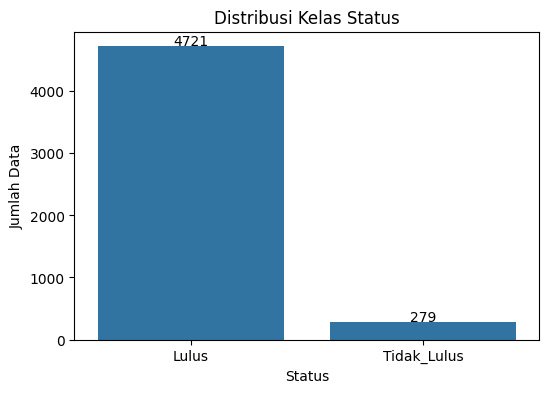

In [3]:
#cek distribusi
target_counts = df["Status"].value_counts()

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Distribusi Kelas Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Data")

# Menampilkan jumlah di atas batang
for i, value in enumerate(target_counts.values):
    ax.text(
        i,
        value + 20,
        str(value),
        ha='center'
    )

plt.show()

In [4]:
#upsampling
lulus = df[df["Status"] == "Lulus"]
tidak_lulus = df[df["Status"] == "Tidak_Lulus"]

tidak_lulus_upsampled = resample(
    tidak_lulus,
    replace=True,
    n_samples=len(lulus),
    random_state=42
)

df_balanced = pd.concat([ lulus, tidak_lulus_upsampled])

print("\nSesudah Upsampling")
print(df_balanced["Status"].value_counts())


Sesudah Upsampling
Status
Lulus          4721
Tidak_Lulus    4721
Name: count, dtype: int64


In [5]:
#pilih fitur
selected_features = [
    'Assignments_Avg', 
    'Midterm_Score', 
    'Final_Score'
]

X = df[selected_features]

y = df["Status"]

In [6]:
#encode target
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
)))

{'Lulus': np.int64(0), 'Tidak_Lulus': np.int64(1)}


In [7]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
#normalisasi
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [9]:
#model MLP
model = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#training
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9344 - loss: 0.3203 - val_accuracy: 0.9463 - val_loss: 0.1666
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.1670 - val_accuracy: 0.9463 - val_loss: 0.1621
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.1581 - val_accuracy: 0.9463 - val_loss: 0.1547
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.1488 - val_accuracy: 0.9475 - val_loss: 0.1493
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9447 - loss: 0.1420 - val_accuracy: 0.9488 - val_loss: 0.1449
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.1384 - val_accuracy: 0.9463 - val_loss: 0.1439
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9444 - loss: 0.1367 - val_accuracy: 0.9450 - val_loss: 0.1424
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9447 - loss: 0.1356 - val_accu

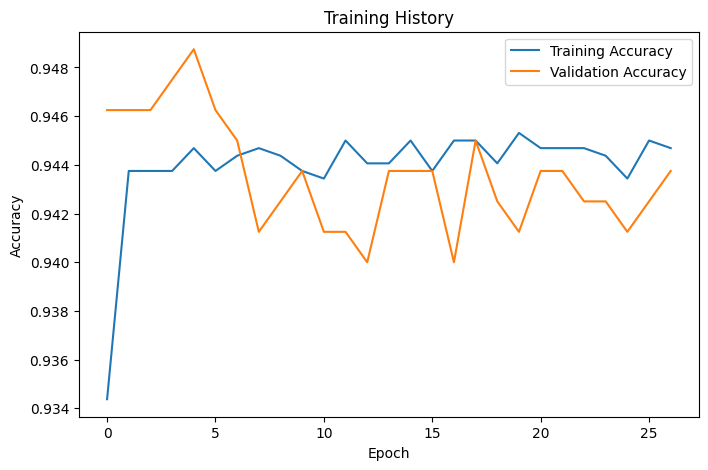

In [11]:
#grafik akurasi
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training History')
plt.legend()

plt.show()

In [12]:
#prediksi
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9360
Precision: 0.3462
Recall   : 0.1607
F1 Score : 0.2195


In [14]:
#classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Tidak Lulus", "Lulus"]
    )
)

              precision    recall  f1-score   support

 Tidak Lulus       0.95      0.98      0.97       944
       Lulus       0.35      0.16      0.22        56

    accuracy                           0.94      1000
   macro avg       0.65      0.57      0.59      1000
weighted avg       0.92      0.94      0.92      1000



In [15]:
# ROC AUC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC Score : {roc_auc:.4f}")

AUC Score : 0.9202


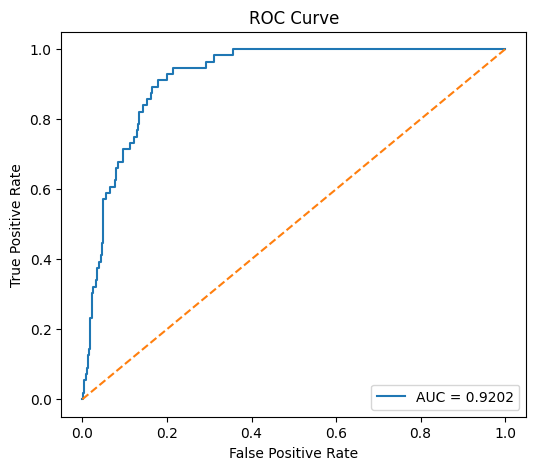

In [16]:
#plot ROC curve
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

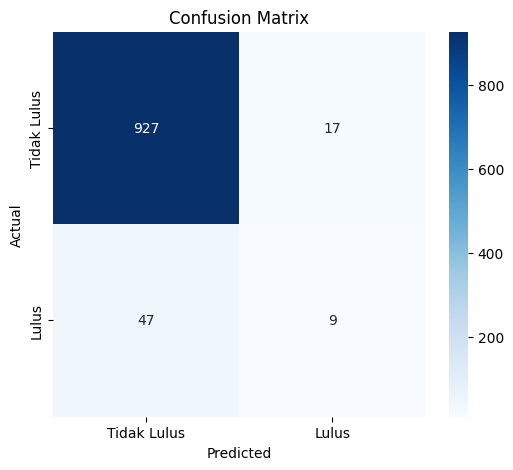

In [17]:
#confussion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Lulus', 'Lulus'],
    yticklabels=['Tidak Lulus', 'Lulus']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [18]:
#save model
model.save(
    "mlp_kelulusan_mahasiswa.keras"
) 